<a href="https://colab.research.google.com/github/kheirbeqaya/Harris-Corner-Detection-Comparison-Custom-vs-OpenCV/blob/main/notebooks/Harris_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

_______ Load image _________

In [1]:
!wget -O Harris_img.png https://vision.middlebury.edu/stereo/data/scenes2021/data/artroom1/im0.png


--2026-04-08 11:38:03--  https://vision.middlebury.edu/stereo/data/scenes2021/data/artroom1/im0.png
Resolving vision.middlebury.edu (vision.middlebury.edu)... 140.233.20.14
Connecting to vision.middlebury.edu (vision.middlebury.edu)|140.233.20.14|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2759093 (2.6M) [image/png]
Saving to: ‘Harris_img.png’

Harris_img.png      100%[===================>]   2.63M  1.60MB/s    in 1.6s    

2026-04-08 11:38:07 (1.60 MB/s) - ‘Harris_img.png’ saved [2759093/2759093]



_____ Define and apply Custom Harris Functions and Detector_______



Custom Harris corners: 593


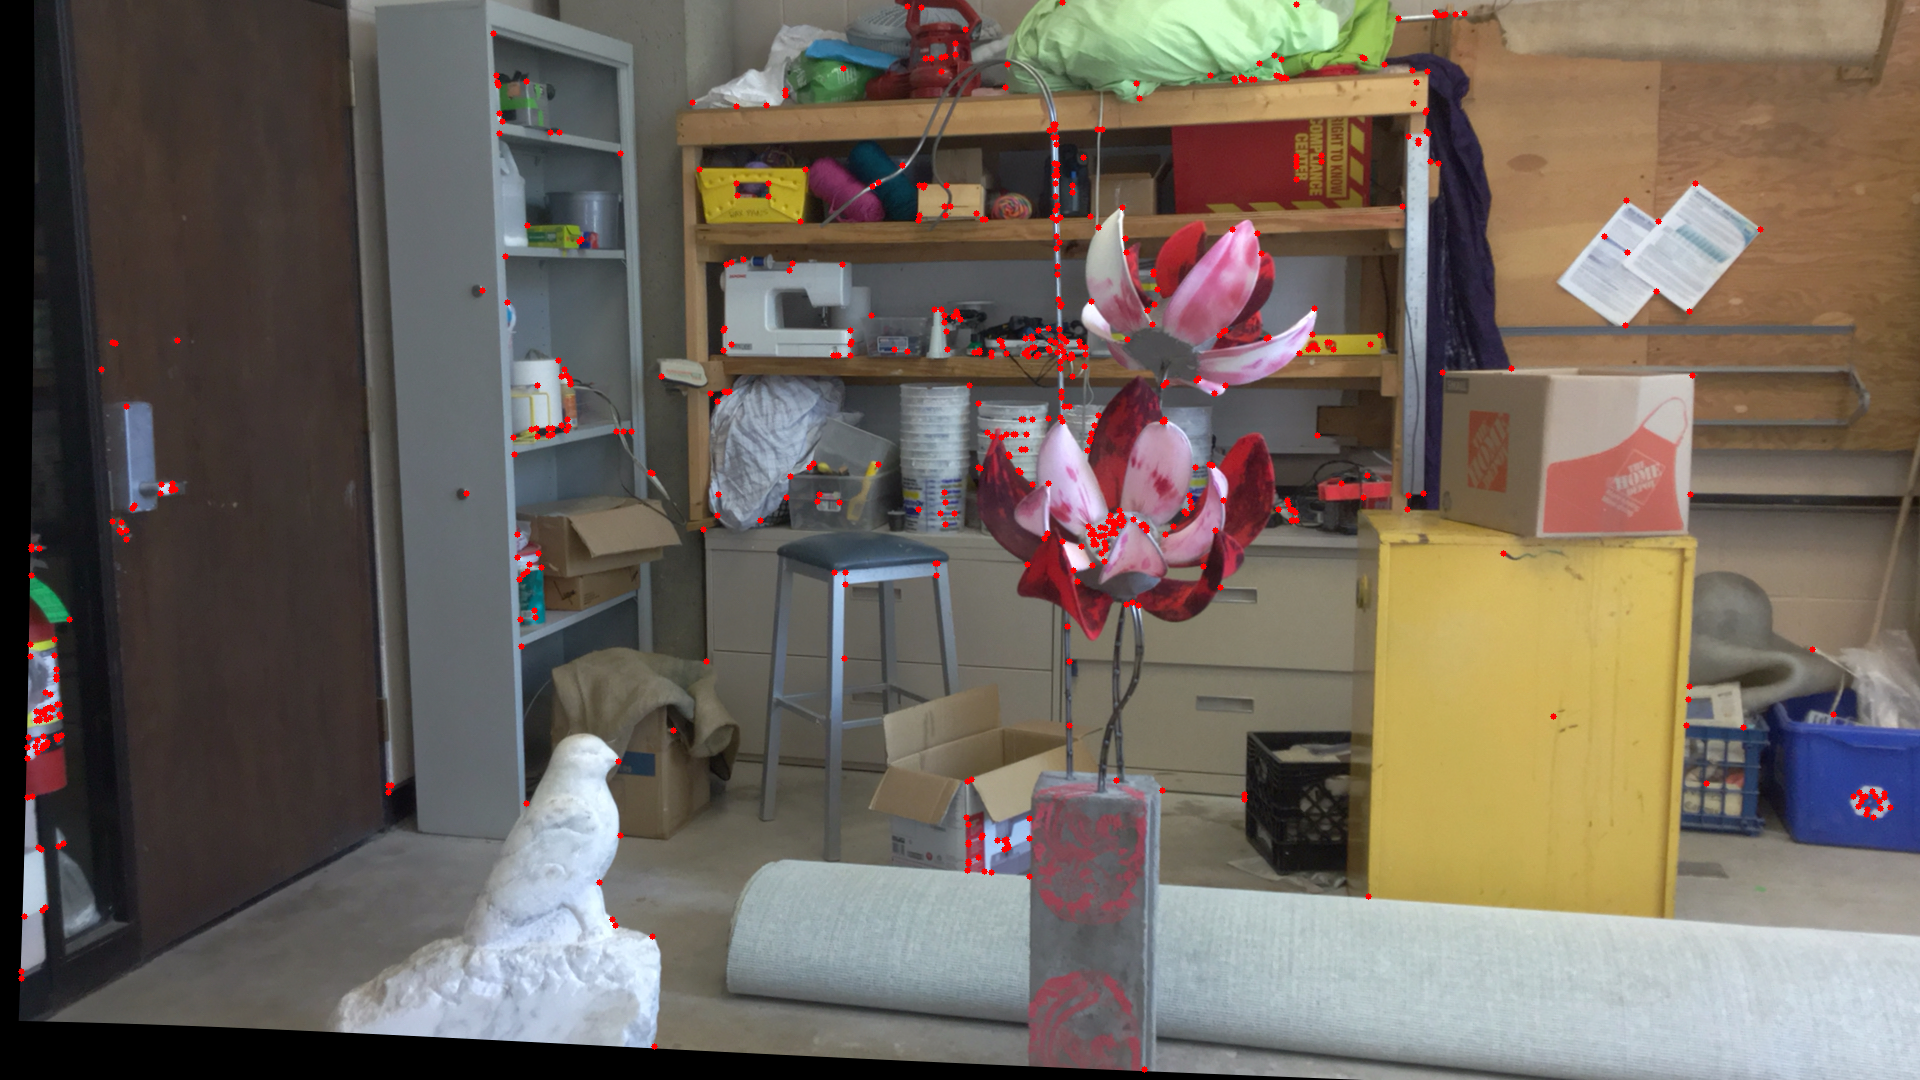

In [2]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow

# gradients
def compute_gradients(image):
    Ix = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    Iy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
    return Ix, Iy

# structure tensor
def compute_structure_tensor(Ix, Iy, window_size=3):
    offset = window_size // 2

    Ixx = Ix**2
    Iyy = Iy**2
    Ixy = Ix * Iy

    h, w = Ix.shape

    Sxx = np.zeros_like(Ix)
    Syy = np.zeros_like(Iy)
    Sxy = np.zeros_like(Ix)

    for y in range(offset, h - offset):
        for x in range(offset, w - offset):
            Sxx[y, x] = np.sum(Ixx[y-offset:y+offset+1, x-offset:x+offset+1])
            Syy[y, x] = np.sum(Iyy[y-offset:y+offset+1, x-offset:x+offset+1])
            Sxy[y, x] = np.sum(Ixy[y-offset:y+offset+1, x-offset:x+offset+1])

    return Sxx, Syy, Sxy

# harris response
def compute_harris_response(Sxx, Syy, Sxy, k=0.04):
    det = (Sxx * Syy) - (Sxy ** 2)
    trace = Sxx + Syy
    return det - k * (trace ** 2)

# NMS
def non_max_suppression(R, threshold):
    corners = []
    h, w = R.shape

    for y in range(1, h - 1):
        for x in range(1, w - 1):
            if R[y, x] > threshold:
                if R[y, x] == np.max(R[y-1:y+2, x-1:x+2]):
                    corners.append((x, y))
    return corners



# read image
image = cv2.imread("Harris_img.png")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

Ix, Iy = compute_gradients(gray)
Sxx, Syy, Sxy = compute_structure_tensor(Ix, Iy)
R = compute_harris_response(Sxx, Syy, Sxy)

threshold = 0.01 * R.max()
corners = non_max_suppression(R, threshold)
print("Custom Harris corners:", len(corners))
image_colored = image.copy()

for (x, y) in corners:
    cv2.circle(image_colored, (x, y), 3, (0, 0, 255), -1)

cv2_imshow(image_colored)

________ Apply OpenCV Harris Detector ________

OpenCV Harris corners: 476


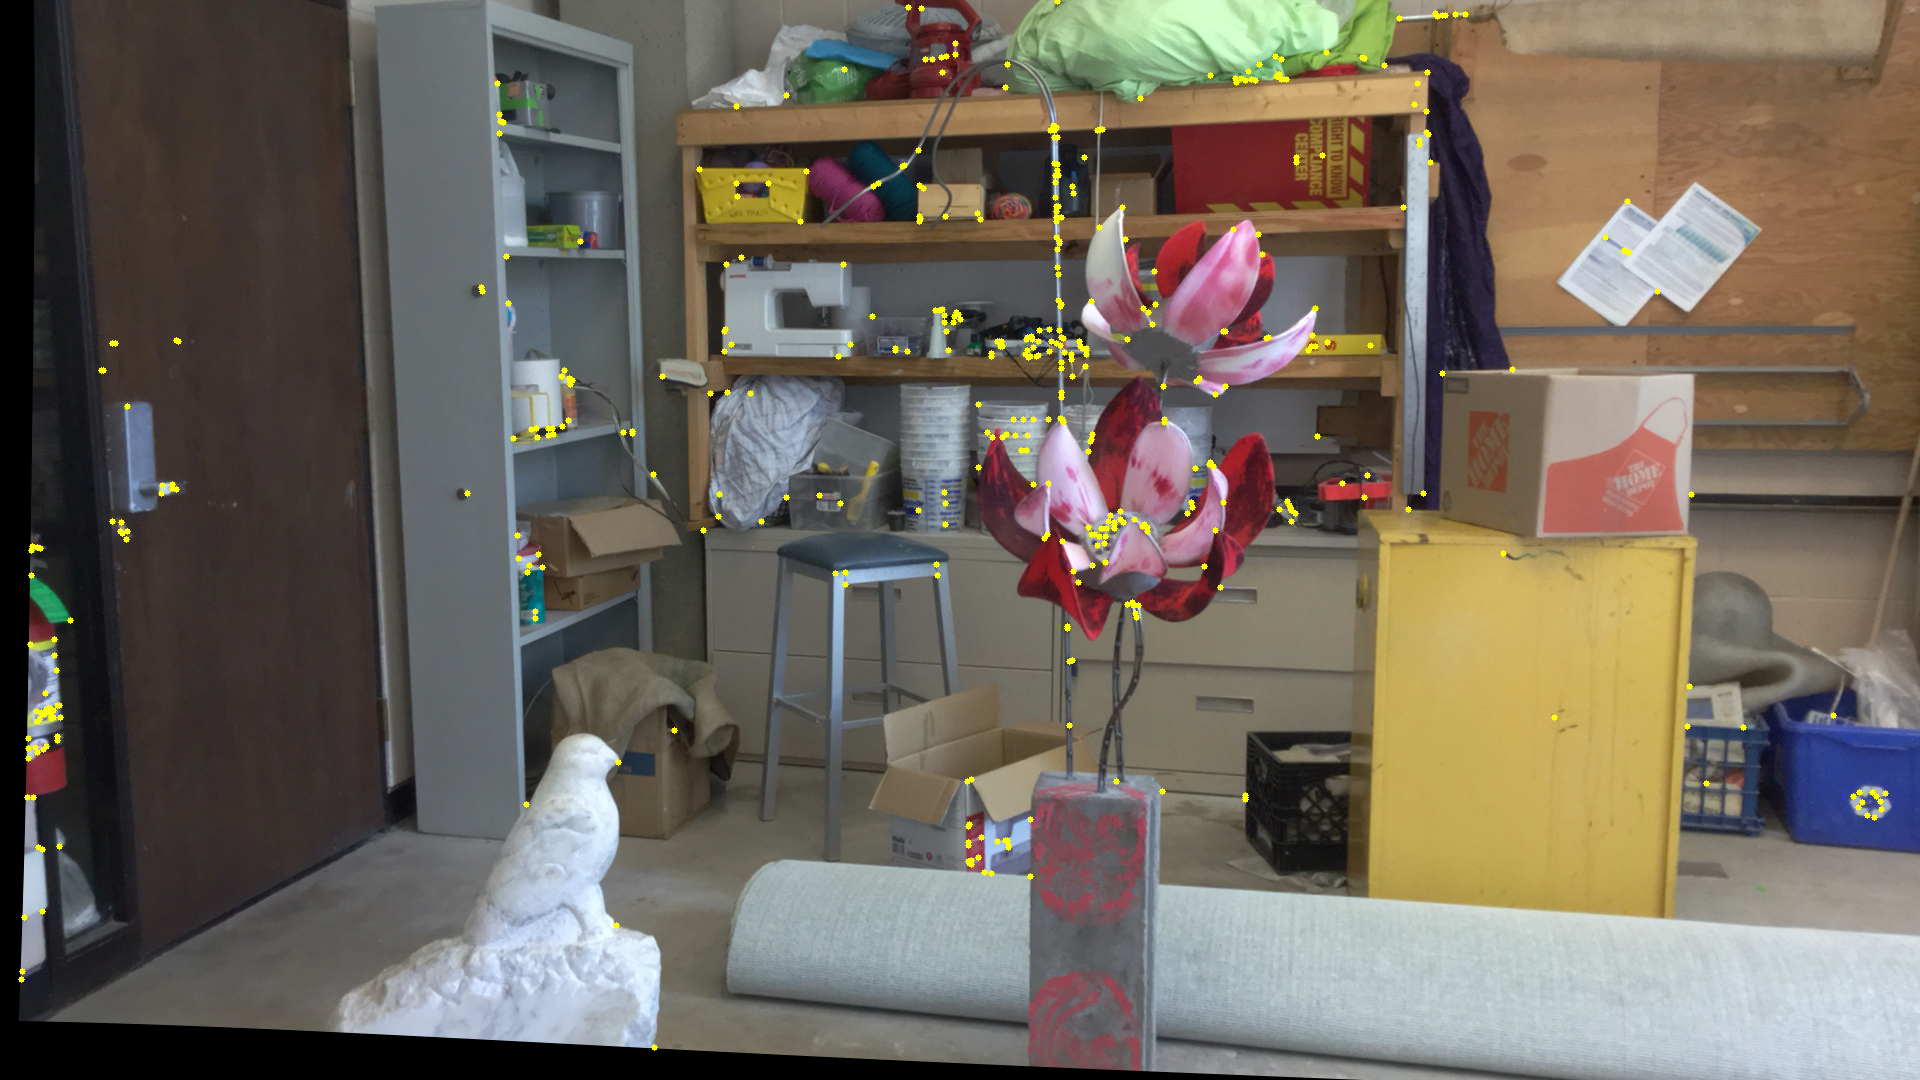

In [3]:
# convert to float32 (required for OpenCV Harris Function)
gray_float = np.float32(gray)

# run OpenCV Harris
harris_cv = cv2.cornerHarris(gray_float, 2, 3, 0.04)

image_cv = image.copy()

# set threshold
threshold = 0.01 * harris_cv.max()

h, w = harris_cv.shape

# store corners
corners_cv = []

for y in range(1, h - 1):
    for x in range(1, w - 1):
        if harris_cv[y, x] > threshold:
            # non-max suppression
            if harris_cv[y, x] == harris_cv[y-1:y+2, x-1:x+2].max():
                corners_cv.append((x, y))

print("OpenCV Harris corners:", len(corners_cv))

# draw corners
for (x, y) in corners_cv:
    cv2.circle(image_cv, (x, y), 3, (0, 255, 255), -1)

# show result
cv2_imshow(image_cv)

_______ Compare Results Side by Side________

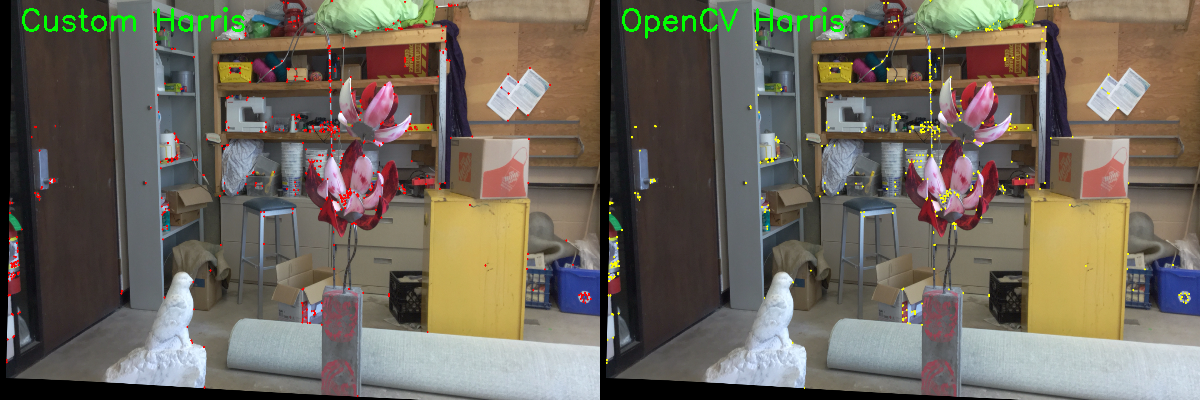

In [4]:
# Comparison
image_resized = cv2.resize(image_colored, (600, 400))
image_cv_resized = cv2.resize(image_cv, (600, 400))
cv2.putText(image_resized, "Custom Harris", (20,30),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

cv2.putText(image_cv_resized, "OpenCV Harris", (20,30),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

# side by side
comparison = np.hstack((image_resized, image_cv_resized))

# show result
cv2_imshow(comparison)


_________ Match Points Between Custom and OpenCV Harris___________

In [5]:
new_w, new_h = 600, 400
h_orig, w_orig = gray.shape
scale_x = new_w / w_orig
scale_y = new_h / h_orig

corners_scaled = [(int(x*scale_x), int(y*scale_y)) for (x,y) in corners]
corners_cv_scaled = [(int(x*scale_x), int(y*scale_y)) for (x,y) in corners_cv]

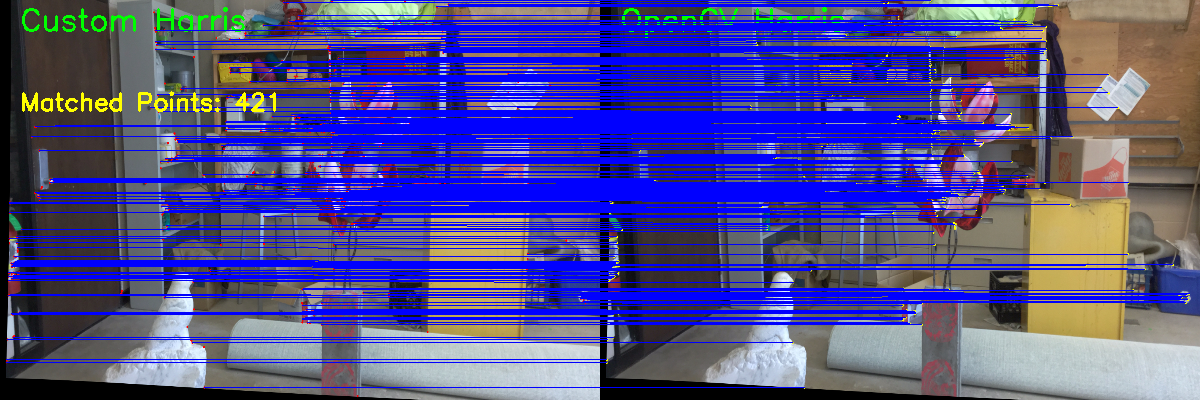

Number of matched points: 421


In [6]:
tolerance = 1
corners_cv_set = set(corners_cv_scaled)
matched_points = []
matched_cv_points = set()  # to avoid duplicate matches
comparison_colored=comparison.copy()
for (x, y) in corners_scaled:
    matched = False
    for dx in range(-tolerance, tolerance+1):
        for dy in range(-tolerance, tolerance+1):
            candidate = (x+dx, y+dy)
            if candidate in corners_cv_set and candidate not in matched_cv_points:
                # draw line
                cv2.line(comparison_colored, (x, y), (candidate[0] + new_w, candidate[1]), (255,0,0), 1)

                matched_points.append((x, y))
                matched_cv_points.add(candidate)  # mark OpenCV point as matched
                matched = True
                break
        if matched:
            break

# number of matched points
cv2.putText(comparison_colored, f"Matched Points: {len(matched_points)}", (20, 110),
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,255), 2)

# show result
cv2_imshow(comparison_colored)


print("Number of matched points:", len(matched_points))